# Lab 1: MLP Regression & Classification

**Name:** Peyton Hoffman

Part 1 continues directly from what you already built — same dataset, same one-hot encoding approach, a regression MLP. Parts 2 and 3 apply that same MLP-building pattern to a new problem type: classification instead of regression. Watch closely for exactly which pieces of the code change, and which stay identical.

## Setup — Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Shared helper: plotting loss (and accuracy, when available)

We'll reuse this for all three parts so the curves are directly comparable.

In [26]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

---
# Part 1 — Regression with One-Hot Encoding (Ames Housing)

In [27]:
ames = fetch_openml(name="house_prices", as_frame=True, parser="auto")
df = ames.frame
df = df[["GrLivArea", "OverallQual", "YearBuilt", "TotalBsmtSF", "GarageCars",
        "Neighborhood", "HouseStyle", "MSZoning", "SalePrice"]].dropna()

categorical_features = ["Neighborhood", "HouseStyle", "MSZoning"]

# One-hot encode
df_onehot = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Spilt the data into Features and Target Variables
X1 = df_onehot.drop(columns=["SalePrice"]).values.astype(float)
y1 = df_onehot["SalePrice"].values.astype(float)

# Print the shape of feature matrix
print("Feature matrix shape:", X1.shape)

Feature matrix shape: (1460, 40)


In [28]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

x1_scaler = StandardScaler()
X1_train_scaled = x1_scaler.fit_transform(X1_train)
X1_test_scaled = x1_scaler.transform(X1_test)

y1_scaler = StandardScaler()
y1_train_scaled = y1_scaler.fit_transform(y1_train.reshape(-1, 1)).flatten()
y1_test_scaled = y1_scaler.transform(y1_test.reshape(-1, 1)).flatten()

**Build your MLP.** Fill in the blanks (`___`) and be ready to justify your choices.

In [29]:
model_reg = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X1_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Q: Why does the output layer have no activation function?
# Your answer: The output layer has no activation function because it regression model. It is not a categroical model choosing between 2 values, the model is just returning a numerical number.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


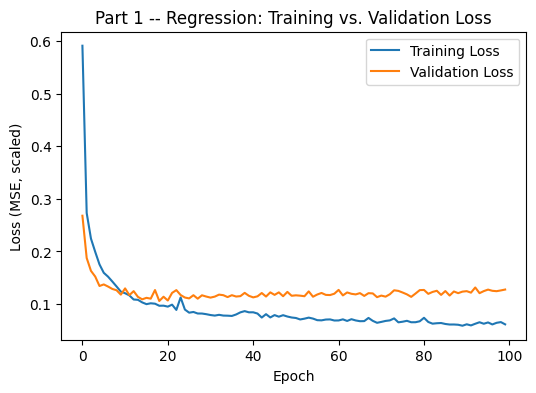

In [30]:
history_reg = model_reg.fit(
    X1_train_scaled, y1_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_reg, "Part 1 -- Regression: Training vs. Validation Loss")

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* It is a good fit because they are nearing 0 and they are very close together following the same path.


In [31]:
preds_scaled = model_reg.predict(X1_test_scaled).flatten()
preds_dollars = y1_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

rmse_reg = np.sqrt(np.mean((preds_dollars - y1_test) ** 2))
mae_reg = np.mean(np.abs(preds_dollars - y1_test))

print(f"Part 1 -- Test RMSE: ${rmse_reg:,.0f}")
print(f"Part 1 -- Test MAE:  ${mae_reg:,.0f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Part 1 -- Test RMSE: $32,601
Part 1 -- Test MAE:  $20,822


---
# Part 2 — Binary Classification (Pima Indians Diabetes)

Predicting whether a patient has diabetes (1) or not (0) from 8 medical measurements.

In [32]:
diabetes = fetch_openml(name="diabetes", version=1, as_frame=True, parser="auto")
df2 = diabetes.frame

print(df2.shape)
print(df2["class"].value_counts())

# Q: How many classes? Is this dataset balanced or imbalanced?
# Your answer: There are 2 classes. The data is imbalanced because there is a much greater number of negative classes then positive classes.


(768, 9)
class
tested_negative    500
tested_positive    268
Name: count, dtype: int64


In [33]:
X2 = df2.drop(columns=["class"]).values.astype(float)
y2 = (df2["class"] == "tested_positive").astype(int).values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Q: Why stratify here? Why did Part 1 not need this?
# Your answer: Since we are looking at a classififcation model it is important to stratify because the output is binary (2) and can/must be divided proportionally. With that we don't need to stratify for a regression model becasue the output is a continious value, there are no classes to stratify.

x2_scaler = StandardScaler()
X2_train_scaled = x2_scaler.fit_transform(X2_train)
X2_test_scaled = x2_scaler.transform(X2_test)

# Note: y2 is NOT scaled here.
# Q: Why not, compared to Part 1's y1_scaler?
# Your answer: y2 is not scaled here compared to part 1's y1_scaler because classification labels must remain as their original class values, while the continuous regression target y1 can benefit from scaling.


**Build your MLP.** Fill in the blanks — this time there are two new ones: the output activation, and the loss function.

In [41]:
# Create the classification model
model_binary = tf.keras.Sequential([
     tf.keras.layers.Dense(64, activation="relu", input_shape=(X2_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_binary.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Q: What output activation did you use, and why does it fit a yes/no prediction?
# Your answer: We used the sigmoid output activation. This activation produces a value between 0 and 1, which represents the yes/no prediction.

# Q: What loss function did you use, and how does it relate to what "sigmoid" outputs?
# Your answer: We used binary_crossentropy. This relates to what "sigmoid" outputs because it compares the probability produced with the actual answer, which is either 0 or 1.


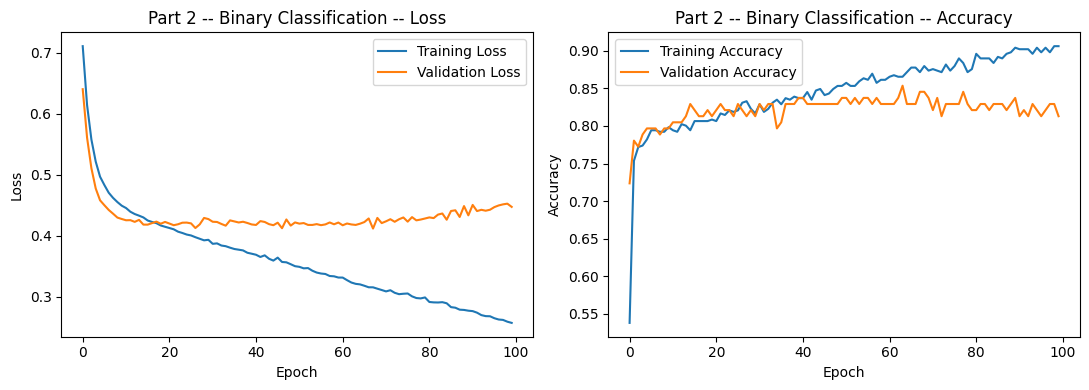

In [42]:
history_binary = model_binary.fit(
    X2_train_scaled, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_binary, "Part 2 -- Binary Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* The graphs are overfitting, because the training loss keeps going down (model memorizing training data), the validation loss starts to go up after some epochs, and the training accuracy is greater than the validation accuracy.


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Part 2 -- Test Accuracy: 0.747


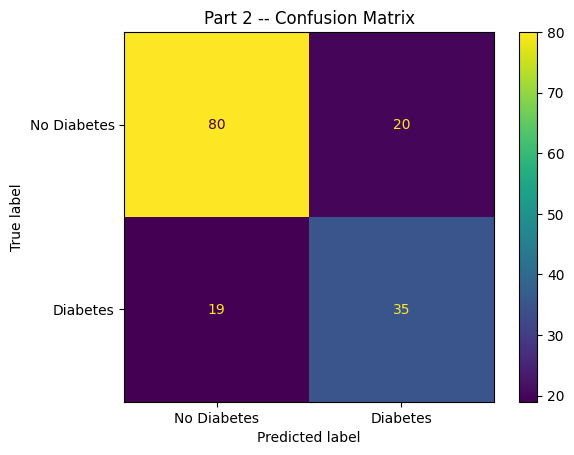

In [44]:
binary_preds = (model_binary.predict(X2_test_scaled).flatten() >= 0.5).astype(int)

acc_binary = accuracy_score(y2_test, binary_preds)
print(f"Part 2 -- Test Accuracy: {acc_binary:.3f}")

cm = confusion_matrix(y2_test, binary_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]).plot()
plt.title("Part 2 -- Confusion Matrix")
plt.show()

# Q: In a medical diagnosis context, are false positives and false negatives
# equally costly? Which would you rather minimize, and why? How might that
# change the 0.5 threshold you'd choose?
# Your answer: False positives and false negatives are not equally costly, we would rather minimize the false negatives because missing a real medical diagnosis could delay necessary treatment.
# If you lower the 0.5 threshold it could predict more people with diabetes (positive diagnosis). However it may increase false positives which can lead to unnecessary testing and treatment.


---
# Part 3 — Multiclass Classification (Wine Quality)

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [45]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [46]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer: There are 3 classes, they are somewhat imbalanced because the high quality (2) only has 217 samples, compared to medium quality (1) of 638, and low quality (0) of 744.


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


**Encode your labels.** We'll use integer labels (0, 1, 2) with `sparse_categorical_crossentropy` — this avoids a separate one-hot encoding step for the labels. (An equally valid alternative: one-hot encode the labels with `to_categorical` and use plain `categorical_crossentropy` instead — same result, different bookkeeping.)

In [47]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

**Build your MLP.** This time, fill in the number of output neurons too — it's no longer fixed at 1.

In [50]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Your answers: There are 3 output neurons that we used because there is one output neuron for each class (low, medium, and high). The number of output neurons must equal n_classes.
# We chose the softmax activation function because it converts the outputs into probabilities for each class that add up to 1.

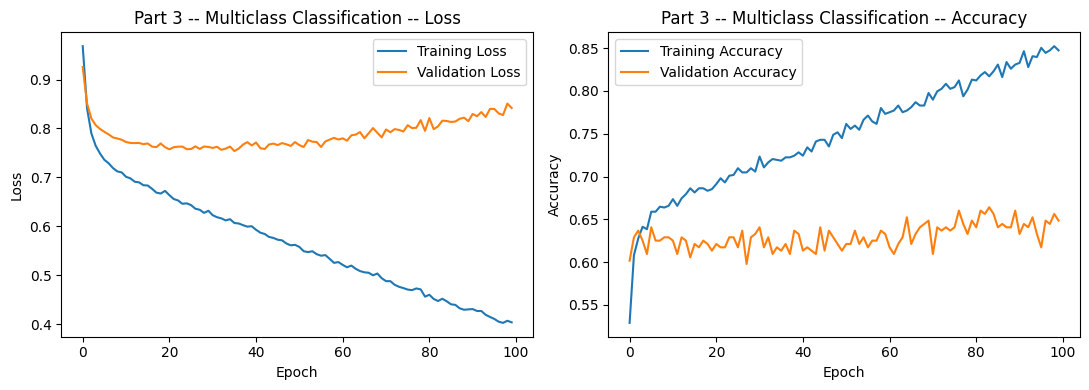

In [51]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* The graphs are overfitting, because the training loss keeps going down (model memorizing training data), the validation loss starts to go up after some epochs, and the training accuracy is greater than the validation accuracy.


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Part 3 -- Test Accuracy: 0.684


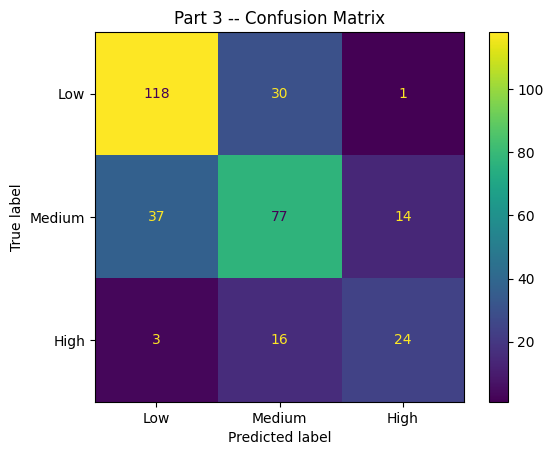

In [53]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Q: Which classes does your model confuse most often? Does that make sense
# given how the quality bands were constructed?
# Your answer: The model confuses the low and medium classes most often. This makes sense because these quality bands are next to each other, so wines
# near the cutoff may have very similar characteristics even though they are placed into different classes.


---
# Comparison & Reflection

Fill in from your own three models:

| | Part 1 (Regression) | Part 2 (Binary) | Part 3 (Multiclass) |
|---|---|---|---|
| Output neurons |1 |1 | 3|
| Output activation |None |sigmoid |softmax |
| Loss function | None|bce |sparse categorical  |
| Label format | numerical values|0 or 1 | 0, 1, 2|
| Evaluation metric(s) | RMSE, MAE| accuracy, confusion matrix| accuracy, confusion matrix|

**Write 4–5 sentences:**

1. What's the general rule connecting the *number of classes* to the *number of output neurons* and the *choice of activation*?
2. Why doesn't regression need an activation function on the output, while both classification tasks do?
3. For Part 3: why might accuracy alone be a misleading metric if your class counts are imbalanced?


The number of output neurons usually matches the number of clases. Binary classification: One output neuron with sigmoid, which produces a probability between 0 and 1. Multiclass classification: One output neuron per class with softmax, which produces class probabilities that add up to 1.

Regression models don't need an activation function because their outputs are a continous numerical value and could be any number. Classification needs an activation function to turn the models raw output into probabilities. Sigmoid produces a probability for a yes/no outcome, while softmax produces probabilities for multiple classes.

Accuracy can be misleading when the classes are imbalanced because the model can achieve high accuracy by mainly predicting the larger classes while performing poorly on the smaller class.





---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.